yuchen gong
final project step 3

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

plt.rcParams["figure.figsize"] = (8, 6)
plt.style.use("default")

In [8]:
df = pd.read_csv("/Users/yuchen/Documents/emory/bios584/diabetes.csv")
df["Diabetes_binary"] = (df["Diabetes_012"] > 0).astype(int)
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0,0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0,0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0,0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0,0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0,0


In [9]:
df = df[(df["BMI"] >= 10) & (df["BMI"] <= 70)]
key_vars = [
    "Diabetes_binary", "BMI", "HighBP", "HighChol",
    "Smoker", "PhysActivity", "Age", "Sex", "Education", "Income"
]
df = df.dropna(subset=key_vars)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 253096 entries, 0 to 253679
Data columns (total 23 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253096 non-null  float64
 1   HighBP                253096 non-null  float64
 2   HighChol              253096 non-null  float64
 3   CholCheck             253096 non-null  float64
 4   BMI                   253096 non-null  float64
 5   Smoker                253096 non-null  float64
 6   Stroke                253096 non-null  float64
 7   HeartDiseaseorAttack  253096 non-null  float64
 8   PhysActivity          253096 non-null  float64
 9   Fruits                253096 non-null  float64
 10  Veggies               253096 non-null  float64
 11  HvyAlcoholConsump     253096 non-null  float64
 12  AnyHealthcare         253096 non-null  float64
 13  NoDocbcCost           253096 non-null  float64
 14  GenHlth               253096 non-null  float64
 15  MentH

In [10]:
df[["BMI", "Age", "Education", "Income"]].describe()

,BMI,Age,Education,Income
count,253096.000000,253096.000000,253096.000000,253096.000000
mean,28.262252,8.035062,5.050262,6.053739
std,6.116067,3.053697,0.985739,2.071036
min,12.000000,1.000000,1.000000,1.000000
25%,24.000000,6.000000,4.000000,5.000000
50%,27.000000,8.000000,5.000000,7.000000
75%,31.000000,10.000000,6.000000,8.000000
max,70.000000,13.000000,6.000000,8.000000


In [11]:
for col in ["Diabetes_binary", "HighBP", "HighChol", "Smoker",
            "PhysActivity", "Sex", "Education", "Income"]:
    print(f"\n{col} value counts (proportion):")
    print(df[col].value_counts(normalize=True).round(3))


Diabetes_binary value counts (proportion):
Diabetes_binary
0    0.842
1    0.158
Name: proportion, dtype: float64

HighBP value counts (proportion):
HighBP
0.0    0.571
1.0    0.429
Name: proportion, dtype: float64

HighChol value counts (proportion):
HighChol
0.0    0.576
1.0    0.424
Name: proportion, dtype: float64

Smoker value counts (proportion):
Smoker
0.0    0.557
1.0    0.443
Name: proportion, dtype: float64

PhysActivity value counts (proportion):
PhysActivity
1.0    0.757
0.0    0.243
Name: proportion, dtype: float64

Sex value counts (proportion):
Sex
0.0    0.56
1.0    0.44
Name: proportion, dtype: float64

Education value counts (proportion):
Education
6.0    0.423
5.0    0.276
4.0    0.247
3.0    0.037
2.0    0.016
1.0    0.001
Name: proportion, dtype: float64

Income value counts (proportion):
Income
8.0    0.356
7.0    0.170
6.0    0.144
5.0    0.102
4.0    0.079
3.0    0.063
2.0    0.046
1.0    0.039
Name: proportion, dtype: float64


In [12]:
X = df[["BMI", "HighBP", "HighChol", "Smoker",
        "PhysActivity", "Age", "Sex", "Education", "Income"]]
y = df["Diabetes_binary"]

X_const = sm.add_constant(X)

logit_model = sm.Logit(y, X_const)
logit_results = logit_model.fit()

logit_results.summary()

Optimization terminated successfully.
         Current function value: 0.358477
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        Diabetes_binary   No. Observations:               253096
Model:                          Logit   Df Residuals:                   253086
Method:                           MLE   Df Model:                            9
Date:                Fri, 05 Dec 2025   Pseudo R-squ.:                  0.1772
Time:                        17:05:59   Log-Likelihood:                -90729.
converged:                       True   LL-Null:                   -1.1027e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -5.1869      0.053    -98.202      0.000      -5.290      -5.083
BMI              0.0869      0.001     90.816      0.000       0.085       0.089
HighBP           0.8330      0.014     61.306      0.000       0.806       0.860
HighChol         0.7004      0.013     55.439      0.000       0.676       0.725
Smoker           0.0588      0.012      4.812      0.000       0.035       0.083
PhysActivity    -0.2064      0.013    -15.669      0.000      -0.232      -0.181
Age              0.1428      0.002     58.082      0.000       0.138       0.148
Sex              0.2705      0.012     21.832      0.000       0.246       0.295
Education       -0.0874      0.007    -13.430      0.000      -0.100      -0.075
Income          -0.1240      0.003    -39.521      0.000      -0.130      -0.118
================================================================================
"""

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.98      0.91     42642
           1       0.55      0.13      0.21      7978

    accuracy                           0.85     50620
   macro avg       0.70      0.55      0.56     50620
weighted avg       0.81      0.85      0.80     50620

Confusion Matrix:
 [[41782   860]
 [ 6946  1032]]


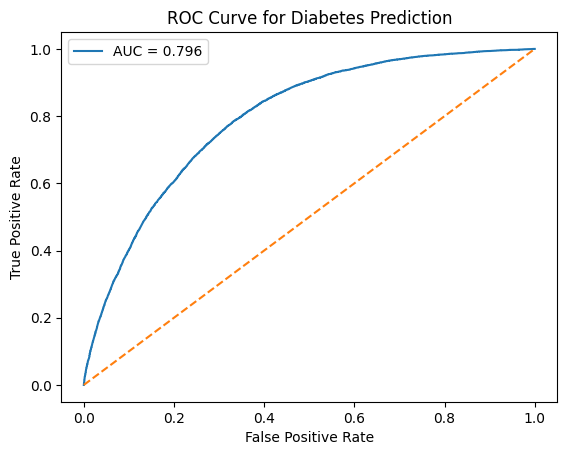

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Diabetes Prediction")
plt.legend()
plt.show()

In [15]:
bmi_yes = df[df["Diabetes_binary"] == 1]["BMI"]
bmi_no  = df[df["Diabetes_binary"] == 0]["BMI"]

t_stat, p_val = stats.ttest_ind(bmi_yes, bmi_no, equal_var=False)
print("T-statistic:", t_stat)
print("P-value:", p_val)

T-statistic: 110.18252126513735
P-value: 0.0


In [16]:
ct = pd.crosstab(df["Diabetes_binary"], df["PhysActivity"])
chi2, p, dof, expected = stats.chi2_contingency(ct)

print("Contingency table:\n", ct)
print("Chi-square:", chi2)
print("P-value:", p)

Contingency table:
 PhysActivity       0.0     1.0
Diabetes_binary               
0                47081  166126
1                14500   25389
Chi-square: 3715.0200673648997
P-value: 0.0


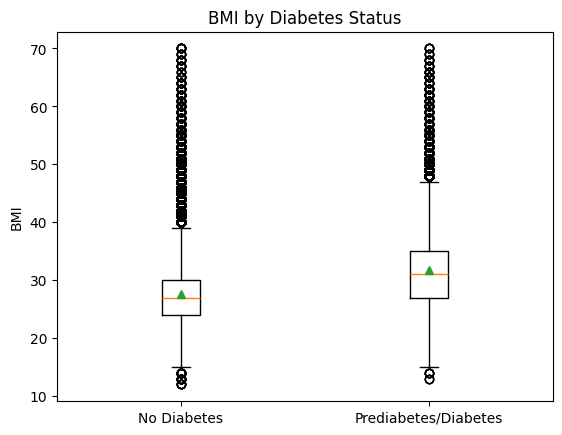

In [18]:
bmi_no  = df[df["Diabetes_binary"] == 0]["BMI"]
bmi_yes = df[df["Diabetes_binary"] == 1]["BMI"]

plt.figure()
plt.boxplot(
    [bmi_no, bmi_yes],
    tick_labels=["No Diabetes", "Prediabetes/Diabetes"],
    showmeans=True
)
plt.ylabel("BMI")
plt.title("BMI by Diabetes Status")
plt.show()

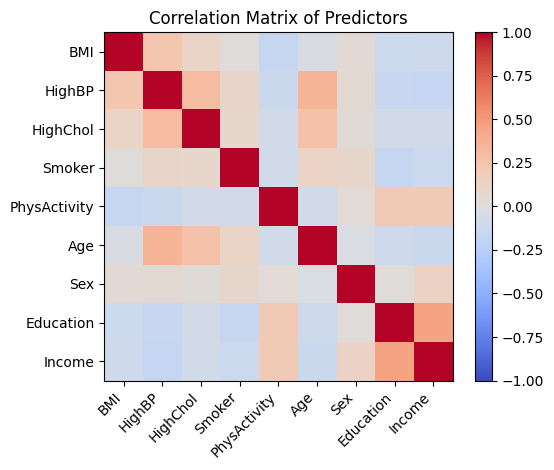

,BMI,HighBP,HighChol,Smoker,PhysActivity,Age,Sex,Education,Income
BMI,1.000000,0.232776,0.115656,0.016448,-0.156552,-0.031615,0.045922,-0.114214,-0.108865
HighBP,0.232776,1.000000,0.298272,0.097145,-0.125193,0.344452,0.052320,-0.141140,-0.170925
HighChol,0.115656,0.298272,1.000000,0.091152,-0.078033,0.272211,0.031217,-0.070734,-0.085364
Smoker,0.016448,0.097145,0.091152,1.000000,-0.087420,0.120661,0.093568,-0.162023,-0.124158
PhysActivity,-0.156552,-0.125193,-0.078033,-0.087420,1.000000,-0.092652,0.032382,0.199834,0.198368
Age,-0.031615,0.344452,0.272211,0.120661,-0.092652,1.000000,-0.027299,-0.101722,-0.127874
Sex,0.045922,0.052320,0.031217,0.093568,0.032382,-0.027299,1.000000,0.019571,0.127059
Education,-0.114214,-0.141140,-0.070734,-0.162023,0.199834,-0.101722,0.019571,1.000000,0.449101
Income,-0.108865,-0.170925,-0.085364,-0.124158,0.198368,-0.127874,0.127059,0.449101,1.000000


In [19]:
corr_vars = ["BMI", "HighBP", "HighChol", "Smoker",
             "PhysActivity", "Age", "Sex", "Education", "Income"]

corr_matrix = df[corr_vars].corr()

plt.figure()
im = plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr_vars)), corr_vars, rotation=45, ha="right")
plt.yticks(range(len(corr_vars)), corr_vars)
plt.title("Correlation Matrix of Predictors")
plt.tight_layout()
plt.show()

corr_matrix